# A/B Test Analysis on Observed Marketing Data

## Business question
Does showing the advertisement (`ad`) improve conversion relative to the public-service announcement (`psa`), and is the estimated uplift large enough to matter in practice?

## Analysis plan

1. validate the input data and experimental groups;
2. compare conversion rates with a two-proportion z-test;
3. estimate a 95% confidence interval for the absolute uplift;
4. compare the effect with the 0.5 percentage-point planning threshold;
5. translate the effect into incremental conversions at clearly defined traffic scales;
6. state a decision together with assumptions and limitations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy.optimize import brentq
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_confint,
    proportion_effectsize,
    proportions_ztest,
)

ALPHA = 0.05
TARGET_POWER = 0.80
BUSINESS_MDE = 0.005  # 0.5 percentage points; scenario assumption from notebook 01


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data" / "raw" / "marketing_AB.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate data/raw/marketing_AB.csv. Run the notebook inside the project repository."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "marketing_AB.csv"
VISUALS_DIR = PROJECT_ROOT / "visuals"
VISUALS_DIR.mkdir(exist_ok=True)

## 1. Load and validate the dataset

The checks below prevent silent errors caused by duplicate users, missing values, unexpected group labels, or inconsistent boolean encoding.

In [2]:
def parse_boolean(series: pd.Series) -> pd.Series:
    '''Return a strict boolean series from common CSV encodings.'''
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    mapping = {
        True: True,
        False: False,
        1: True,
        0: False,
        "true": True,
        "false": False,
        "t": True,
        "f": False,
        "1": True,
        "0": False,
    }
    normalized = series.map(
        lambda value: value.strip().lower() if isinstance(value, str) else value
    )
    converted = normalized.map(mapping)
    if converted.isna().any():
        invalid_values = sorted(normalized[converted.isna()].astype(str).unique())
        raise ValueError(f"Unsupported converted values: {invalid_values}")
    return converted.astype(bool)


required_columns = {
    "user id",
    "test group",
    "converted",
    "total ads",
    "most ads day",
    "most ads hour",
}

df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.str.match(r"^Unnamed")].copy()

missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

df["converted"] = parse_boolean(df["converted"])

quality_checks = pd.Series(
    {
        "Rows": len(df),
        "Unique users": df["user id"].nunique(),
        "Duplicate user IDs": int(df["user id"].duplicated().sum()),
        "Missing values": int(df[list(required_columns)].isna().sum().sum()),
        "Minimum total ads": int(df["total ads"].min()),
        "Maximum total ads": int(df["total ads"].max()),
        "Minimum most-ads hour": int(df["most ads hour"].min()),
        "Maximum most-ads hour": int(df["most ads hour"].max()),
    },
    name="value",
).to_frame()

expected_groups = {"ad", "psa"}
observed_groups = set(df["test group"].unique())
if observed_groups != expected_groups:
    raise ValueError(f"Unexpected group labels: {sorted(observed_groups)}")
if df["user id"].duplicated().any():
    raise ValueError("Duplicate user IDs detected.")
if df[list(required_columns)].isna().any().any():
    raise ValueError("Missing values detected in required columns.")
if not df["most ads hour"].between(0, 23).all():
    raise ValueError("most ads hour contains values outside 0-23.")
if not df["total ads"].ge(1).all():
    raise ValueError("total ads contains non-positive values.")

quality_checks

,value
Rows,588101
Unique users,588101
Duplicate user IDs,0
Missing values,0
Minimum total ads,1
Maximum total ads,2065
Minimum most-ads hour,0
Maximum most-ads hour,23


In [3]:
group_summary = (
    df.groupby("test group", observed=True)
    .agg(
        users=("user id", "size"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean"),
        median_total_ads=("total ads", "median"),
        mean_total_ads=("total ads", "mean"),
    )
    .sort_index()
)
group_summary["traffic_share"] = group_summary["users"] / len(df)
group_summary

,users,conversions,conversion_rate,median_total_ads,mean_total_ads,traffic_share
test group,,,,,,
ad,564577,14423,0.025547,13.0,24.823365,0.96
psa,23524,420,0.017854,12.0,24.761138,0.04


The treatment allocation is highly uneven: roughly 96% of users are in `ad` and 4% in `psa`. The statistical test supports unequal sample sizes, but this design is less efficient than a balanced design for a fixed total sample when per-user costs are similar. The smaller control group is the main constraint on precision.

## 2. Primary effect estimate

The null hypothesis is that both groups have the same conversion probability. A two-sided pooled z-test is used to test whether the observed conversion rates differ.

The absolute effect is reported as the difference between the two conversion rates, together with a 95% confidence interval calculated using the Newcombe method

In [4]:
n_ad = int(group_summary.loc["ad", "users"])
n_psa = int(group_summary.loc["psa", "users"])
converted_ad = int(group_summary.loc["ad", "conversions"])
converted_psa = int(group_summary.loc["psa", "conversions"])
rate_ad = float(group_summary.loc["ad", "conversion_rate"])
rate_psa = float(group_summary.loc["psa", "conversion_rate"])

absolute_uplift = rate_ad - rate_psa
relative_uplift = absolute_uplift / rate_psa

z_statistic, p_value = proportions_ztest(
    count=np.array([converted_ad, converted_psa]),
    nobs=np.array([n_ad, n_psa]),
    alternative="two-sided",
)

ci_low, ci_high = confint_proportions_2indep(
    count1=converted_ad,
    nobs1=n_ad,
    count2=converted_psa,
    nobs2=n_psa,
    method="newcomb",
    compare="diff",
    alpha=ALPHA,
)

results = pd.DataFrame(
    {
        "metric": [
            "Ad conversion rate",
            "PSA conversion rate",
            "Absolute uplift",
            "Relative uplift",
            "95% CI for absolute uplift",
            "z statistic",
            "p-value",
        ],
        "value": [
            f"{rate_ad:.3%}",
            f"{rate_psa:.3%}",
            f"{absolute_uplift * 100:.3f} pp",
            f"{relative_uplift:.1%}",
            f"[{ci_low * 100:.3f}, {ci_high * 100:.3f}] pp",
            f"{z_statistic:.3f}",
            f"{p_value:.3e}",
        ],
    }
)
results

,metric,value
0,Ad conversion rate,2.555%
1,PSA conversion rate,1.785%
2,Absolute uplift,0.769 pp
3,Relative uplift,43.1%
4,95% CI for absolute uplift,"[0.587, 0.936] pp"
5,z statistic,7.370
6,p-value,1.705e-13


### Interpretation

The ad group achieved a 2.555% conversion rate compared with 1.785% in the PSA group. This corresponds to an absolute uplift of 0.769 percentage points and a relative uplift of 43.1%. The result is statistically significant, and the 95% confidence interval for the absolute uplift ranges from 0.587 to 0.936 percentage points.

## 3. Detectable effect with the observed sample size

Given the actual number of users in each group, I calculated the smallest positive uplift that the experiment could detect with 80% power at a 5% significance level.

This is a sensitivity check based on the observed group sizes. It is not a post-hoc power calculation based on the observed result.

In [5]:
allocation_ratio = n_ad / n_psa
power_analysis = NormalIndPower()

detectable_h = power_analysis.solve_power(
    nobs1=n_psa,
    alpha=ALPHA,
    power=TARGET_POWER,
    ratio=allocation_ratio,
    alternative="two-sided",
)


def effect_size_gap(candidate_treatment_rate: float) -> float:
    return proportion_effectsize(candidate_treatment_rate, rate_psa) - detectable_h


detectable_treatment_rate = brentq(
    effect_size_gap,
    rate_psa + 1e-12,
    min(rate_psa + 0.10, 0.999999),
)
detectable_uplift = detectable_treatment_rate - rate_psa

sensitivity_summary = pd.DataFrame(
    {
        "metric": [
            "Observed allocation (ad:psa)",
            "80% detectable absolute uplift",
            "Planning MDE from notebook 01",
            "Observed absolute uplift",
        ],
        "value": [
            f"{allocation_ratio:.1f}:1",
            f"{detectable_uplift * 100:.3f} pp",
            f"{BUSINESS_MDE * 100:.3f} pp",
            f"{absolute_uplift * 100:.3f} pp",
        ],
    }
)
sensitivity_summary

,metric,value
0,Observed allocation (ad:psa),24.0:1
1,80% detectable absolute uplift,0.255 pp
2,Planning MDE from notebook 01,0.500 pp
3,Observed absolute uplift,0.769 pp


## 4. Practical impact

The dataset does not include revenue, margin, advertising cost, or dates, so it is not possible to calculate ROI.

Instead, I translate the observed uplift into an estimated number of additional conversions:

- for users who were actually assigned to the `ad` group;
- for the full sample, assuming the same uplift applied to all users.

These values are estimates based on the observed difference between groups, not directly observed conversion counts.

In [6]:
total_users = len(df)

impact = pd.DataFrame(
    {
        "scenario": [
            "Observed treated-user scale",
            "Full-sample traffic scale",
        ],
        "users": [n_ad, total_users],
    }
)
impact["estimated_incremental_conversions"] = impact["users"] * absolute_uplift
impact["ci_low"] = impact["users"] * ci_low
impact["ci_high"] = impact["users"] * ci_high
impact = impact.round(
    {
        "estimated_incremental_conversions": 0,
        "ci_low": 0,
        "ci_high": 0,
    }
)
impact

,scenario,users,estimated_incremental_conversions,ci_low,ci_high
0,Observed treated-user scale,564577,4343.0,3316.0,5284.0
1,Full-sample traffic scale,588101,4524.0,3454.0,5505.0


# 5. Decision and limitations

## What the results suggest

The ad group achieved a higher conversion rate than the PSA group. The observed uplift was statistically significant and exceeded the 0.5 percentage-point planning threshold used in this project.

However, this does not automatically mean that the advertisement should be rolled out everywhere. The dataset does not show how users were assigned to groups and does not include advertising costs, revenue, dates, or other business metrics.

Before making a final rollout decision, I would confirm:

- that users were randomly assigned and tracking worked correctly;
- that the value of an additional conversion is higher than the advertising cost;
- that the advertisement does not negatively affect other important metrics;
- that the uplift is stable over time and across key user segments.

Based on the available data, the recommendation is therefore a **conditional rollout**, not an unconditional launch.

## What the dataset cannot tell us

1. **Random assignment cannot be verified.**  
   The file contains group labels, but it does not explain how users were assigned. A causal interpretation therefore depends on the assumption that the experiment was properly randomized.

2. **There are no dates.**  
   We cannot check trends, seasonality, experiment duration, or calculate a daily or monthly impact.

3. **Profitability cannot be calculated.**  
   The dataset does not contain revenue, margin, conversion value, or advertising cost.

4. **The groups are highly imbalanced.**  
   The statistical test remains valid, but the small PSA group provides less precision than a more balanced design.

5. **`total ads` was measured after group assignment.**  
      The actual number of exposures (`total ads`) may have depended on user activity, targeting, or campaign rules, not only on experiment-group assignment. Therefore, a higher conversion rate among users with more exposures does not prove that showing more ads caused more conversions.

6. **The result may not generalize to other settings.**  
   The estimated effect applies to the users and campaign represented in this dataset. More evidence would be needed before assuming the same result in other populations or time periods.

## 6. Recruiter-facing visualizations

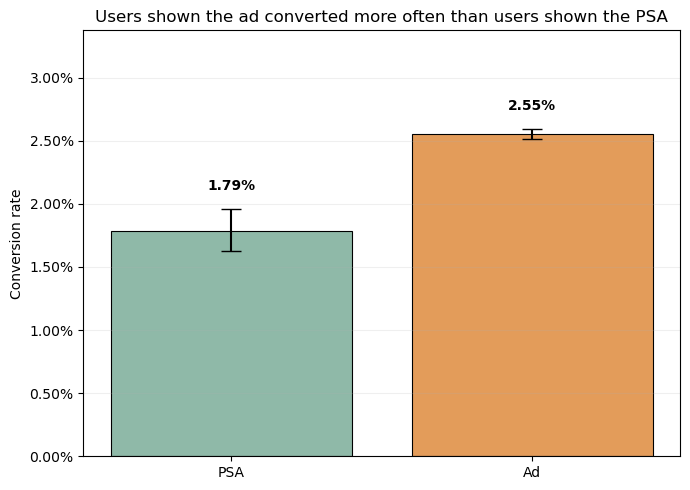

Saved: visuals\conversion_rates.png


In [ ]:
plot_rows = []
for group, count, nobs, rate in [
    ("PSA", converted_psa, n_psa, rate_psa),
    ("Ad", converted_ad, n_ad, rate_ad),
]:
    lower, upper = proportion_confint(count, nobs, alpha=ALPHA, method="wilson")
    plot_rows.append(
        {
            "group": group,
            "rate": rate,
            "lower": lower,
            "upper": upper,
        }
    )

plot_data = pd.DataFrame(plot_rows)

fig, ax = plt.subplots(figsize=(7, 5))
positions = np.arange(len(plot_data))

errors = np.vstack(
    [
        plot_data["rate"] - plot_data["lower"],
        plot_data["upper"] - plot_data["rate"],
    ]
)

bar_colors = ["#8FB9A8", "#E39C5A"]  

bars = ax.bar(
    positions,
    plot_data["rate"],
    yerr=errors,
    capsize=7,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
)


for bar, rate, upper in zip(bars, plot_data["rate"], plot_data["upper"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        upper + 0.0012,
        f"{rate:.2%}",
        ha="center",
        va="bottom",
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", pad=1.5),
    )

ax.set_xticks(positions, plot_data["group"])
ax.set_ylabel("Conversion rate")
ax.set_title("Users shown the ad converted more often than users shown the PSA")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, plot_data["upper"].max() * 1.30)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()

conversion_plot_path = VISUALS_DIR / "conversion_rates.png"
fig.savefig(conversion_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {conversion_plot_path.relative_to(PROJECT_ROOT)}")

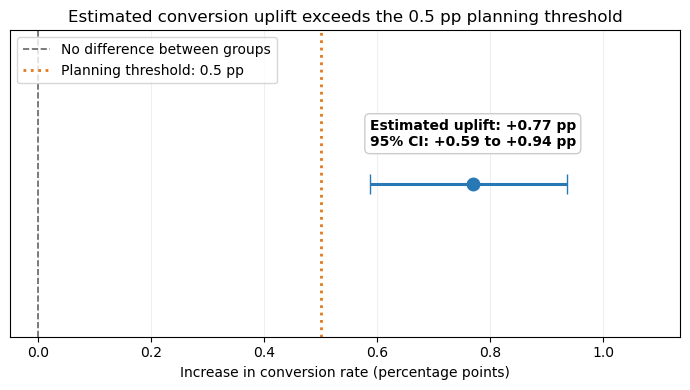

Saved: visuals\effect_estimate.png


In [8]:
uplift_pp = absolute_uplift * 100
ci_low_pp = ci_low * 100
ci_high_pp = ci_high * 100
threshold_pp = BUSINESS_MDE * 100

fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(
    x=uplift_pp,
    y=0,
    xerr=np.array(
        [[uplift_pp - ci_low_pp], [ci_high_pp - uplift_pp]]
    ),
    fmt="o",
    markersize=9,
    capsize=7,
    linewidth=2.2,
    color="#2878B5",
    ecolor="#2878B5",
)

# Reference lines
ax.axvline(
    0,
    color="#666666",
    linestyle="--",
    linewidth=1.2,
    label="No difference between groups",
)

ax.axvline(
    threshold_pp,
    color="#E07A1F",
    linestyle=":",
    linewidth=2,
    label=f"Planning threshold: {threshold_pp:.1f} pp",
)

ax.annotate(
    (
        f"Estimated uplift: +{uplift_pp:.2f} pp\n"
        f"95% CI: +{ci_low_pp:.2f} to +{ci_high_pp:.2f} pp"
    ),
    xy=(uplift_pp, 0),
    xytext=(0, 25),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontweight="bold",
    bbox={
        "facecolor": "white",
        "edgecolor": "#CCCCCC",
        "boxstyle": "round,pad=0.35",
    },
)

ax.set_yticks([])
ax.set_xlabel("Increase in conversion rate (percentage points)")
ax.set_title(
    "Estimated conversion uplift exceeds the 0.5 pp planning threshold"
)

ax.set_xlim(
    min(-0.05, ci_low_pp - 0.15),
    ci_high_pp + 0.20,
)

ax.grid(axis="x", alpha=0.2)
ax.legend(loc="upper left")
fig.tight_layout()

effect_plot_path = VISUALS_DIR / "effect_estimate.png"
fig.savefig(effect_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {effect_plot_path.relative_to(PROJECT_ROOT)}")

## Final conclusion

The ad group converted at 2.55%, compared with 1.79% in the PSA group. This is an increase of 0.77 percentage points, or about 43% relative to the PSA conversion rate.

The estimated uplift is likely to be between 0.59 and 0.94 percentage points, and the entire range is above the 0.5 percentage-point planning threshold used in this project.